# PSI Thin-Limit Scan

Extract the 10 `PSI_thinlimit_1e7` runs, read the sample radius, height, and wall thickness from each `mccode.sim`, and compute the expected intensity in one spherical-monitor longitude bin using the same Born estimate as before:

`expected = intensity_hitting_sample * P_interact * solid_angle_bin / (4*pi)`


In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Folder containing separately run thin-limit simulations.
# This can contain numeric run folders or named folders such as HST/PSI_1e-6.
run_root = Path('HST')
if not run_root.exists():
    run_root = Path('geometry_optimization/PSI_instrument/thinlimit/HST')

# Same constants/conventions used in PSI_instrument_plots.ipynb.

sigma_inc_cm_inv = 0.368
sigma_abs_cm_inv = 0.367
sigma_coh_cm_inv = 0.0
sigma_total_cm_inv = sigma_inc_cm_inv + sigma_abs_cm_inv + sigma_coh_cm_inv
use_linear_probability = False
# Path-length mode for the Born probability:
# 'volume_over_projected_area', 'beam_weighted', or 'interpolated_beam_weighted'.
path_length_mode = 'volume_over_projected_area'
beam_weight_record_names = ('sample_flux_hitting_sample', 'sample_flux_before')
# Fine quadrature grid for interpolated beam weighting. Higher values better resolve thin walls/lids.
beam_weight_interpolated_grid_shape = (1600, 1600)
# Keep the central Born value from path_length_mode, but add a systematic
# expected-intensity uncertainty from non-uniform beam illumination.
include_beam_profile_systematic = False
beam_profile_systematic_path_mode = 'interpolated_beam_weighted'

# How to propagate monitor pixel errors when summing bins.
# 'independent_pixels' reproduces sqrt(sum sigma_i^2).
# 'correlated_latitude_bins' treats latitude bins inside each longitude column as correlated.
# 'correlated_longitude_bins' treats longitude columns in the detector windows as correlated.
# 'fully_correlated_pixels' treats all selected pixels as correlated.
monitor_error_correlation_mode = 'independent_pixels'

include_lids = True
# Lid thickness as a percentage of the cylindrical wall thickness.
lid_thickness_percent_of_wall = 100.0

latitude_halfwidth_deg = 2.0
# Exclude latitude bins with |latitude| > 90 - pole_cut_deg from corrected spherical plots.
pole_cut_deg = 30.0
apply_cosine_correction = True
cosine_floor = 1e-6
window_center_deg = 75.0
window_width_deg = 60.0

# Stretched exponential fit setting for the main ratio plot.
# If False, fit R(t)=c + A*exp(-(k*t)^p) and report R(0)=c+A.
# If True, fit R(t)=c + (1-c)*exp(-(k*t)^p), so R(0)=1.
stretched_fit_enforce_thin_limit = False

# Linear thin-limit fit region in instrument input units [m].
thin_linear_fit_thickness_range_m = (0, 1e-5)

mask_direct_beam = False
direct_beam_center_spherical = (0.0, 0.0)
direct_beam_spherical_width_deg = 6.0
direct_beam_spherical_height_deg = 10.0

print(run_root.resolve())


/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST


In [3]:
def parse_mccode_params(sim_file):
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with Path(sim_file).open('r') as f:
        for line in f:
            match = pattern.match(line)
            if match:
                try:
                    params[match.group(1)] = float(match.group(2))
                except ValueError:
                    pass
    return params


def _parse_float_tuple(text, n):
    return tuple(float(value) for value in text.split(':', 1)[1].split()[:n])


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = None
    nx = ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            meta['header_total'] = values[0]
            meta['header_error'] = values[1] if len(values) > 1 else np.nan
            meta['header_counts'] = values[2] if len(values) > 2 else np.nan

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if stripped and not stripped.startswith('#'):
            rows.append([float(value) for value in stripped.split()])
    data = np.array(rows, dtype=float)

    if monitor_type and monitor_type.startswith('array_1d'):
        x = data[:, 0] if data.ndim == 2 and data.shape[1] >= 2 else np.arange(data.size)
        intensity = data[:, 1] if data.ndim == 2 and data.shape[1] >= 2 else data.reshape(-1)
        meta.update({'kind': '1d', 'x': x, 'I': intensity, 'total': float(np.nansum(intensity))})
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None
    meta.update({'kind': '2d', 'I': intensity, 'I_err': error, 'N': counts, 'total': float(np.nansum(intensity))})
    return meta


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if np.isfinite(record.get('header_error', np.nan)):
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float) ** 2)))
    return np.nan


def load_records(run_dir):
    records = {}
    for dat_file in Path(run_dir).glob('*.dat'):
        record = parse_mccode_dat(dat_file)
        records[dat_file.stem] = record
        if record.get('component'):
            records[record['component']] = record
    return records


def first_available_record(records, names):
    for name in names:
        if name in records:
            return records[name]
    raise KeyError(f'None of these records were found: {names}')


def coordinate_centers(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_y, n_x = record['I'].shape
    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)
    return 0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:]), x_edges, y_edges


In [4]:
def geometry_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def lid_thickness_cm(geometry):
    return geometry['wall_thickness_cm'] * lid_thickness_percent_of_wall / 100.0


def inner_height_cm(geometry):
    H = geometry['outer_height_cm']
    t_lid = lid_thickness_cm(geometry) if include_lids else 0.0
    return H - 2.0 * t_lid


def side_wall_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    t_wall = geometry['wall_thickness_cm']
    r = R - t_wall
    H_inner = inner_height_cm(geometry)
    if r <= 0 or H_inner < 0:
        return np.nan
    return np.pi * (R**2 - r**2) * H_inner


def lid_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    t_lid = lid_thickness_cm(geometry)
    H_inner = inner_height_cm(geometry)
    if t_lid <= 0:
        return 0.0
    if H_inner < 0:
        return np.nan
    return 2.0 * np.pi * R**2 * t_lid


def sample_material_volume_cm3(geometry):
    if include_lids:
        R = geometry['outer_radius_cm']
        H = geometry['outer_height_cm']
        t_wall = geometry['wall_thickness_cm']
        r = R - t_wall
        H_inner = inner_height_cm(geometry)
        if r <= 0 or H_inner < 0:
            return np.nan
        return np.pi * R**2 * H - np.pi * r**2 * H_inner
    return side_wall_volume_cm3(geometry)


def projected_area_cm2(geometry):
    return 2.0 * geometry['outer_radius_cm'] * geometry['outer_height_cm']


def mean_path_length_cm(geometry):
    return sample_material_volume_cm3(geometry) / projected_area_cm2(geometry)


def material_path_map_cm(x_centers, y_centers, geometry):
    x = np.asarray(x_centers, dtype=float)
    y = np.asarray(y_centers, dtype=float)

    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t_wall = geometry['wall_thickness_cm']
    t_lid = lid_thickness_cm(geometry) if include_lids else 0.0
    r = max(R - t_wall, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_outer_height = np.abs(y) <= 0.5 * H

    if include_lids and t_lid > 0.0:
        in_lid = (np.abs(y) >= 0.5 * H - t_lid) & (np.abs(y) <= 0.5 * H)
        in_side_wall = in_outer_height & ~in_lid
        path = np.outer(in_side_wall.astype(float), side_path)
        path += np.outer(in_lid.astype(float), outer_chord)
    else:
        path = np.outer(in_outer_height.astype(float), side_path)

    return path


def beam_path_length_map_cm(record, geometry):
    x_centers, y_centers, _, _ = coordinate_centers(record)
    return material_path_map_cm(x_centers, y_centers, geometry)


def interpolate_beam_intensity(record, x_new, y_new):
    x_centers, y_centers, _, _ = coordinate_centers(record)
    intensity = np.asarray(record['I'], dtype=float)
    intensity = np.where(np.isfinite(intensity) & (intensity > 0.0), intensity, 0.0)

    interp_x = np.vstack([
        np.interp(x_new, x_centers, row, left=0.0, right=0.0)
        for row in intensity
    ])
    interp_xy = np.vstack([
        np.interp(y_new, y_centers, interp_x[:, col], left=0.0, right=0.0)
        for col in range(interp_x.shape[1])
    ]).T
    return interp_xy


def beam_weighted_mean_path_length_cm(records, geometry):
    beam_record = first_available_record(records, beam_weight_record_names)
    intensity = np.asarray(beam_record['I'], dtype=float)
    path = beam_path_length_map_cm(beam_record, geometry)
    valid = np.isfinite(intensity) & np.isfinite(path) & (intensity > 0.0) & (path > 0.0)
    total_weight = float(np.nansum(intensity[valid]))
    if total_weight <= 0.0:
        return np.nan
    return float(np.nansum(intensity[valid] * path[valid]) / total_weight)


def interpolated_beam_weighted_mean_path_length_cm(records, geometry):
    beam_record = first_available_record(records, beam_weight_record_names)
    x_centers, y_centers, x_edges, y_edges = coordinate_centers(beam_record)

    nx_fine, ny_fine = beam_weight_interpolated_grid_shape
    x_min = max(x_edges[0], -geometry['outer_radius_cm'])
    x_max = min(x_edges[-1], geometry['outer_radius_cm'])
    y_min = max(y_edges[0], -0.5 * geometry['outer_height_cm'])
    y_max = min(y_edges[-1], 0.5 * geometry['outer_height_cm'])
    if x_min >= x_max or y_min >= y_max:
        return np.nan

    x_fine = np.linspace(x_min, x_max, int(nx_fine))
    y_fine = np.linspace(y_min, y_max, int(ny_fine))
    intensity_fine = interpolate_beam_intensity(beam_record, x_fine, y_fine)
    path_fine = material_path_map_cm(x_fine, y_fine, geometry)

    valid = (
        np.isfinite(intensity_fine)
        &
        np.isfinite(path_fine)
        &
        (intensity_fine > 0.0)
        &
        (path_fine > 0.0)
    )
    total_weight = float(np.nansum(intensity_fine[valid]))
    if total_weight <= 0.0:
        return np.nan
    return float(np.nansum(intensity_fine[valid] * path_fine[valid]) / total_weight)


def selected_mean_path_length_cm(geometry, records=None):
    if path_length_mode == 'volume_over_projected_area':
        return mean_path_length_cm(geometry)
    if path_length_mode == 'beam_weighted':
        if records is None:
            raise ValueError('beam_weighted path length requires monitor records')
        return beam_weighted_mean_path_length_cm(records, geometry)
    if path_length_mode == 'interpolated_beam_weighted':
        if records is None:
            raise ValueError('interpolated_beam_weighted path length requires monitor records')
        return interpolated_beam_weighted_mean_path_length_cm(records, geometry)
    raise ValueError(f"Unknown path_length_mode: {path_length_mode!r}")


def path_length_for_mode(geometry, records, mode):
    if mode == 'volume_over_projected_area':
        return mean_path_length_cm(geometry)
    if mode == 'beam_weighted':
        return beam_weighted_mean_path_length_cm(records, geometry)
    if mode == 'interpolated_beam_weighted':
        return interpolated_beam_weighted_mean_path_length_cm(records, geometry)
    raise ValueError(f"Unknown path length mode: {mode!r}")


def interaction_probability_from_path_length(path_length_cm):
    if use_linear_probability:
        return sigma_inc_cm_inv * path_length_cm
    total_probability = 1.0 - np.exp(-sigma_total_cm_inv * path_length_cm)
    return total_probability * sigma_inc_cm_inv / sigma_total_cm_inv


def interaction_probability(geometry, records=None):
    length = selected_mean_path_length_cm(geometry, records)
    return interaction_probability_from_path_length(length)


def intensity_hitting_sample(records):
    before = records['sample_flux_before']
    after = records['sample_flux_after_unscattered']
    before_total = record_total(before)
    after_total = record_total(after)
    before_error = record_total_error(before)
    after_error = record_total_error(after)
    error = np.sqrt(before_error**2 + after_error**2) if np.isfinite(before_error) and np.isfinite(after_error) else np.nan
    return before_total - after_total, error, before_total, after_total


def valid_latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return np.abs(lat_centers) <= 90.0 - pole_cut_deg


def latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return (np.abs(lat_centers) <= latitude_halfwidth_deg) & valid_latitude_mask(record)


def corrected_band_solid_angle_per_longitude_sr(record, lat_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    dlon = np.deg2rad((x_max - x_min) / n_lon)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    omega = 0.0
    for i, use_bin in enumerate(lat_mask):
        if not use_bin:
            continue
        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])
        bin_omega = dlon * (np.sin(lat2) - np.sin(lat1))
        if apply_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < cosine_floor:
                continue
            bin_omega /= cos_lat
        omega += bin_omega
    return float(omega)


def observed_latitude_band_profile(record, lat_mask):
    lon_centers, lat_centers, _, _ = coordinate_centers(record)
    image = np.asarray(record['I'], dtype=float).copy()
    error = None if record.get('I_err') is None else np.asarray(record['I_err'], dtype=float).copy()

    if mask_direct_beam:
        center_lon, center_lat = direct_beam_center_spherical
        lon_beam = np.abs(angular_delta_deg(lon_centers, center_lon)) <= direct_beam_spherical_width_deg / 2.0
        lat_beam = np.abs(lat_centers - center_lat) <= direct_beam_spherical_height_deg / 2.0
        beam_mask = np.outer(lat_beam, lon_beam)
        image[beam_mask] = np.nan
        if error is not None:
            error[beam_mask] = np.nan

    if apply_cosine_correction:
        cos_lat = np.cos(np.deg2rad(lat_centers))
        valid = np.abs(cos_lat) >= cosine_floor
        image[valid, :] /= cos_lat[valid, None]
        image[~valid, :] = np.nan
        if error is not None:
            error[valid, :] /= cos_lat[valid, None]
            error[~valid, :] = np.nan

    profile = np.nansum(image[lat_mask, :], axis=0)
    if error is None:
        profile_error = None
    elif monitor_error_correlation_mode in ('correlated_latitude_bins', 'fully_correlated_pixels'):
        profile_error = np.nansum(np.abs(error[lat_mask, :]), axis=0)
    else:
        profile_error = np.sqrt(np.nansum(error[lat_mask, :] ** 2, axis=0))
    return lon_centers, profile, profile_error


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def symmetric_window_mask(longitude):
    half_width = window_width_deg / 2.0
    positive = np.abs(angular_delta_deg(longitude, window_center_deg)) <= half_width
    negative = np.abs(angular_delta_deg(longitude, -window_center_deg)) <= half_width
    return positive | negative


def expected_intensity_for_run(run_dir):
    records = load_records(run_dir)
    spherical = first_available_record(records, ('sample_spherical_monitor_scattered', 'sample_spherical_monitor'))
    geometry = geometry_cm(run_dir)
    hit, hit_error, before, after = intensity_hitting_sample(records)
    lat_mask = latitude_mask(spherical)
    omega = corrected_band_solid_angle_per_longitude_sr(spherical, lat_mask)
    mean_path = selected_mean_path_length_cm(geometry, records)
    probability = interaction_probability_from_path_length(mean_path)
    expected = hit * probability * omega / (4.0 * np.pi)

    longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
    lon_mask = symmetric_window_mask(longitude)
    n_window_bins = int(np.count_nonzero(lon_mask))
    observed_window_sum = float(np.nansum(profile[lon_mask]))
    expected_window_sum = float(expected * n_window_bins)
    expected_window_sum_stat_error = (
        expected_window_sum * hit_error / hit
        if hit > 0 and np.isfinite(hit_error)
        else np.nan
    )

    beam_profile_mean_path = np.nan
    expected_window_sum_beam_profile_sys = 0.0
    if include_beam_profile_systematic:
        try:
            beam_profile_mean_path = path_length_for_mode(
                geometry,
                records,
                beam_profile_systematic_path_mode,
            )
            beam_profile_probability = interaction_probability_from_path_length(beam_profile_mean_path)
            beam_profile_expected_window_sum = float(
                hit * beam_profile_probability * omega * n_window_bins / (4.0 * np.pi)
            )
            expected_window_sum_beam_profile_sys = abs(
                beam_profile_expected_window_sum - expected_window_sum
            )
        except Exception as exc:
            print(f'Beam-profile systematic skipped for {run_dir}: {exc}')
            expected_window_sum_beam_profile_sys = np.nan

    expected_window_sum_error = np.sqrt(
        np.nansum([
            expected_window_sum_stat_error**2,
            expected_window_sum_beam_profile_sys**2,
        ])
    )
    observed_mean = observed_window_sum / n_window_bins if n_window_bins > 0 else np.nan
    observed_mean_error = np.nan
    observed_window_sum_error = np.nan
    if profile_error is not None:
        if monitor_error_correlation_mode in ('correlated_longitude_bins', 'fully_correlated_pixels'):
            observed_window_sum_error = float(np.nansum(np.abs(profile_error[lon_mask])))
        else:
            observed_window_sum_error = float(np.sqrt(np.nansum(profile_error[lon_mask] ** 2)))
        observed_mean_error = observed_window_sum_error / n_window_bins if n_window_bins > 0 else np.nan
    observed_over_expected = observed_window_sum / expected_window_sum if expected_window_sum > 0 else np.nan
    observed_over_expected_stat_err = np.nan
    observed_over_expected_beam_profile_sys_err = np.nan
    observed_over_expected_err = np.nan
    if expected_window_sum > 0 and observed_window_sum > 0:
        if np.isfinite(observed_window_sum_error) and np.isfinite(expected_window_sum_stat_error):
            observed_over_expected_stat_err = observed_over_expected * np.sqrt(
                (observed_window_sum_error / observed_window_sum)**2
                +
                (expected_window_sum_stat_error / expected_window_sum)**2
            )
        if np.isfinite(expected_window_sum_beam_profile_sys):
            observed_over_expected_beam_profile_sys_err = (
                observed_over_expected
                *
                expected_window_sum_beam_profile_sys
                /
                expected_window_sum
            )
        if np.isfinite(observed_over_expected_stat_err) or np.isfinite(observed_over_expected_beam_profile_sys_err):
            observed_over_expected_err = np.sqrt(
                np.nansum([
                    observed_over_expected_stat_err**2,
                    observed_over_expected_beam_profile_sys_err**2,
                ])
            )

    run_dir = Path(run_dir)

    return {
        'run': run_dir.name,
        'run_dir': str(run_dir),
        'radius_cm': geometry['outer_radius_cm'],
        'height_cm': geometry['outer_height_cm'],
        'thickness_cm': geometry['wall_thickness_cm'],
        'lid_thickness_cm': lid_thickness_cm(geometry) if include_lids else 0.0,
        'side_wall_volume_cm3': side_wall_volume_cm3(geometry),
        'lid_volume_cm3': lid_volume_cm3(geometry) if include_lids else 0.0,
        'material_volume_cm3': sample_material_volume_cm3(geometry),
        'mean_path_cm': mean_path,
        'beam_profile_mean_path_cm': beam_profile_mean_path,
        'path_length_mode': path_length_mode,
        'beam_profile_systematic_path_mode': beam_profile_systematic_path_mode,
        'P_interact': probability,
        'I_before': before,
        'I_after_unscattered': after,
        'I_hit': hit,
        'I_hit_err': hit_error,
        'solid_angle_per_lon_bin_sr': omega,
        'expected_per_lon_bin': expected,
        'expected_window_sum': expected_window_sum,
        'expected_window_sum_stat_err': expected_window_sum_stat_error,
        'expected_window_sum_beam_profile_sys': expected_window_sum_beam_profile_sys,
        'expected_window_sum_err': expected_window_sum_error,
        'observed_window_sum': observed_window_sum,
        'observed_window_sum_err': observed_window_sum_error,
        'observed_window_mean_per_lon_bin': observed_mean,
        'observed_window_mean_err': observed_mean_error,
        'observed_over_expected': observed_over_expected,
        'observed_over_expected_stat_err': observed_over_expected_stat_err,
        'observed_over_expected_beam_profile_sys_err': observed_over_expected_beam_profile_sys_err,
        'observed_over_expected_err': observed_over_expected_err,
        'n_window_bins': n_window_bins,
    }


In [5]:
def discover_run_dirs(root):
    root = Path(root)
    run_dirs = sorted({path.parent for path in root.rglob('mccode.sim')})
    return sorted(run_dirs, key=lambda path: (geometry_cm(path)['wall_thickness_cm'], str(path)))


run_dirs = discover_run_dirs(run_root)
rows = []
for run_dir in run_dirs:
    try:
        rows.append(expected_intensity_for_run(run_dir))
    except Exception as exc:
        print(f'Skipping {run_dir}: {exc}')

results = pd.DataFrame(rows).sort_values('thickness_cm').reset_index(drop=True)
if results.empty:
    raise ValueError(f'No usable runs found under {run_root.resolve()}')

display(results)

print(f'Run root: {run_root.resolve()}')
print(f'Runs: {len(results)}')
print(f"Radius: {results['radius_cm'].iloc[0]:.6g} cm")
print(f"Height: {results['height_cm'].iloc[0]:.6g} cm")
print(f"Thickness range: {results['thickness_cm'].min():.6g} to {results['thickness_cm'].max():.6g} cm")
print(f"Include lids: {include_lids}")
print(f"Path length mode: {path_length_mode}")
print(f"Beam-profile systematic: {include_beam_profile_systematic} ({beam_profile_systematic_path_mode})")
print(f"Monitor error correlation mode: {monitor_error_correlation_mode}")
print(f"Lid thickness: {lid_thickness_percent_of_wall:g}% of wall thickness")
print(f"Solid angle per longitude bin: {results['solid_angle_per_lon_bin_sr'].iloc[0]:.6g} sr")


,run,run_dir,radius_cm,height_cm,thickness_cm,lid_thickness_cm,side_wall_volume_cm3,lid_volume_cm3,material_volume_cm3,mean_path_cm,...,expected_window_sum_err,observed_window_sum,observed_window_sum_err,observed_window_mean_per_lon_bin,observed_window_mean_err,observed_over_expected,observed_over_expected_stat_err,observed_over_expected_beam_profile_sys_err,observed_over_expected_err,n_window_bins
0,PSI_1e-8_1e10n,HST/PSI_1e-8_1e10n,1.0,1.0,0.000001,0.000001,0.000006,0.000006,0.000013,0.000006,...,0.000107,0.352973,0.000273,0.005693,0.000004,1.006619,0.000837,0.0,0.000837,62
1,PSI_2e-8,HST/PSI_2e-8,1.0,1.0,0.000002,0.000002,0.000013,0.000013,0.000025,0.000013,...,0.000675,0.690055,0.001505,0.011130,0.000024,0.983948,0.002346,0.0,0.002346,62
2,PSI_5e-8,HST/PSI_5e-8,1.0,1.0,0.000005,0.000005,0.000031,0.000031,0.000063,0.000031,...,0.001688,1.694835,0.003502,0.027336,0.000056,0.966123,0.002202,0.0,0.002202,62
3,PSI_1e-7,HST/PSI_1e-7,1.0,1.0,0.000010,0.000010,0.000063,0.000063,0.000126,0.000063,...,0.003377,3.390156,0.008444,0.054680,0.000136,0.966095,0.002580,0.0,0.002580,62
4,PSI_2e-7,HST/PSI_2e-7,1.0,1.0,0.000020,0.000020,0.000126,0.000126,0.000251,0.000126,...,0.006753,6.748992,0.017154,0.108855,0.000277,0.962185,0.002615,0.0,0.002615,62
5,PSI_5e-7,HST/PSI_5e-7,1.0,1.0,0.000050,0.000050,0.000314,0.000314,0.000628,0.000314,...,0.016880,16.875306,0.038952,0.272182,0.000628,0.962693,0.002408,0.0,0.002408,62
6,PSI_1e-6,HST/PSI_1e-6,1.0,1.0,0.000100,0.000100,0.000628,0.000628,0.001256,0.000628,...,0.033751,33.293320,0.059247,0.536989,0.000956,0.949856,0.001922,0.0,0.001922,62
7,PSI_2e-6,HST/PSI_2e-6,1.0,1.0,0.000200,0.000200,0.001256,0.001257,0.002513,0.001256,...,0.067483,66.132549,0.113485,1.066654,0.001830,0.943407,0.001856,0.0,0.001856,62
8,PSI_5e-6,HST/PSI_5e-6,1.0,1.0,0.000500,0.000500,0.003138,0.003142,0.006279,0.003140,...,0.168520,162.072128,0.251165,2.614067,0.004051,0.925232,0.001688,0.0,0.001688,62
9,PSI_1e-5,HST/PSI_1e-5,1.0,1.0,0.001000,0.001000,0.006267,0.006283,0.012551,0.006275,...,0.336458,313.159519,0.436207,5.050960,0.007036,0.896276,0.001518,0.0,0.001518,62


Run root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST
Runs: 16
Radius: 1 cm
Height: 1 cm
Thickness range: 1e-06 to 0.1 cm
Include lids: True
Path length mode: volume_over_projected_area
Beam-profile systematic: False (interpolated_beam_weighted)
Monitor error correlation mode: independent_pixels
Lid thickness: 100% of wall thickness
Solid angle per longitude bin: 0.00243682 sr


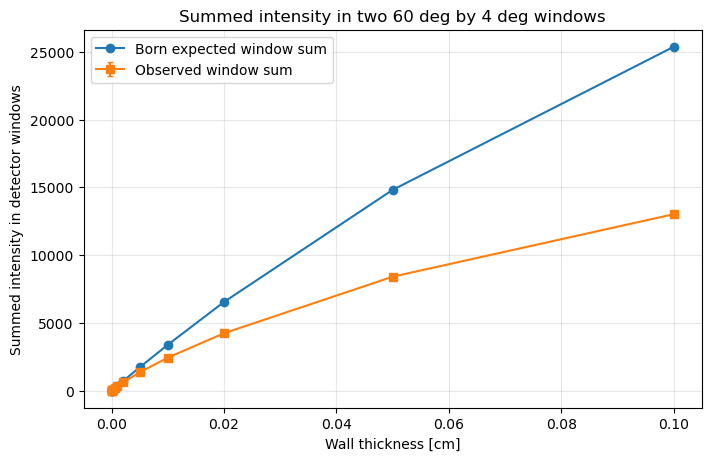

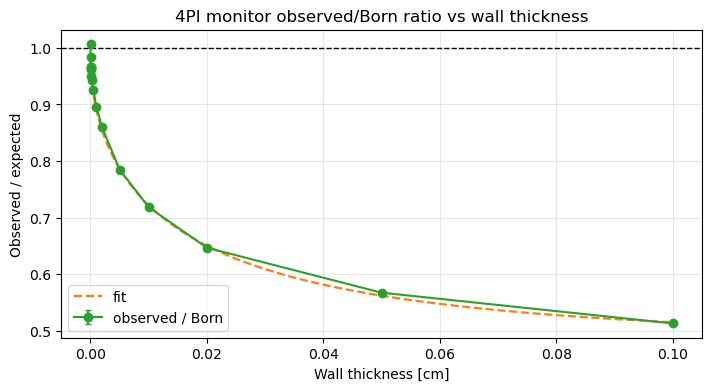

Stretched-exponential fit to observed/Born ratio:
  c:             0.48204068
  A:             0.49787861
  k [1/cm]:      57.689165
  p:             0.57
  R(0)=c+A:      0.97991929
  chi2_nu:       19.52006
  fit points:    15
  fit parameters:4


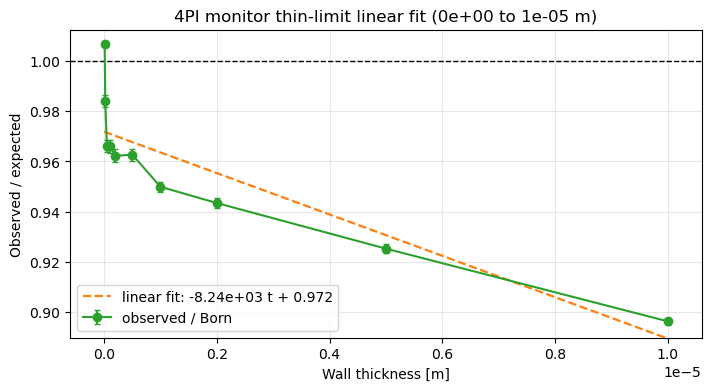

Summed 60 deg by 4 deg detector-window comparison for all discovered runs; linear fit range is 0e+00 to 1e-05 m


,run,thickness_m,used_in_linear_fit,material_volume_cm3,mean_path_cm,beam_profile_mean_path_cm,solid_angle_per_lon_bin_sr,solid_angle_window_sr,expected_window_sum,expected_window_sum_stat_err,expected_window_sum_beam_profile_sys,expected_window_sum_err,observed_window_sum,observed_window_sum_err,observed_over_expected,observed_over_expected_stat_err,observed_over_expected_beam_profile_sys_err,observed_over_expected_err
0,PSI_1e-8_1e10n,1.000000e-08,True,0.000013,0.000006,NaN,0.002437,0.151083,0.350652,0.000107,0.0,0.000107,0.352973,0.000273,1.006619,0.000837,0.0,0.000837
1,PSI_2e-8,2.000000e-08,True,0.000025,0.000013,NaN,0.002437,0.151083,0.701313,0.000675,0.0,0.000675,0.690055,0.001505,0.983948,0.002346,0.0,0.002346
2,PSI_5e-8,5.000000e-08,True,0.000063,0.000031,NaN,0.002437,0.151083,1.754265,0.001688,0.0,0.001688,1.694835,0.003502,0.966123,0.002202,0.0,0.002202
3,PSI_1e-7,1.000000e-07,True,0.000126,0.000063,NaN,0.002437,0.151083,3.509134,0.003377,0.0,0.003377,3.390156,0.008444,0.966095,0.002580,0.0,0.002580
4,PSI_2e-7,2.000000e-07,True,0.000251,0.000126,NaN,0.002437,0.151083,7.014238,0.006753,0.0,0.006753,6.748992,0.017154,0.962185,0.002615,0.0,0.002615
5,PSI_5e-7,5.000000e-07,True,0.000628,0.000314,NaN,0.002437,0.151083,17.529275,0.016880,0.0,0.016880,16.875306,0.038952,0.962693,0.002408,0.0,0.002408
6,PSI_1e-6,1.000000e-06,True,0.001256,0.000628,NaN,0.002437,0.151083,35.050924,0.033751,0.0,0.033751,33.293320,0.059247,0.949856,0.001922,0.0,0.001922
7,PSI_2e-6,2.000000e-06,True,0.002513,0.001256,NaN,0.002437,0.151083,70.099689,0.067483,0.0,0.067483,66.132549,0.113485,0.943407,0.001856,0.0,0.001856
8,PSI_5e-6,5.000000e-06,True,0.006279,0.003140,NaN,0.002437,0.151083,175.169171,0.168520,0.0,0.168520,162.072128,0.251165,0.925232,0.001688,0.0,0.001688
9,PSI_1e-5,1.000000e-05,True,0.012551,0.006275,NaN,0.002437,0.151083,349.400585,0.336458,0.0,0.336458,313.159519,0.436207,0.896276,0.001518,0.0,0.001518


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(results['thickness_cm'], results['expected_window_sum'], 'o-', label='Born expected window sum')
ax.errorbar(
    results['thickness_cm'],
    results['observed_window_sum'],
    yerr=results['observed_window_sum_err'],
    fmt='s-',
    capsize=2,
    label='Observed window sum',
)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Summed intensity in detector windows')
ax.set_title(f'Summed intensity in two {window_width_deg:g} deg by {2 * latitude_halfwidth_deg:g} deg windows')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
fit_x = results['thickness_cm'].to_numpy(dtype=float)
fit_y = results['observed_over_expected'].to_numpy(dtype=float)
fit_mask = np.isfinite(fit_x) & np.isfinite(fit_y) & (fit_y > 0.0) & (fit_y < 1.0)
stretched_fit_summary = None

fit_yerr = results['observed_over_expected_err'].to_numpy(dtype=float)
ax.errorbar(
    fit_x,
    fit_y,
    yerr=fit_yerr,
    fmt='o-',
    color='tab:green',
    capsize=2,
    label='observed / Born',
)
if fit_mask.sum() >= 2:
    x_fit = fit_x[fit_mask]
    y_fit = fit_y[fit_mask]
    yerr_fit = fit_yerr[fit_mask]
    weights = np.where(np.isfinite(yerr_fit) & (yerr_fit > 0.0), 1.0 / yerr_fit**2, 1.0)

    p_grid = np.linspace(0.25, 2.5, 226)
    best = None

    if stretched_fit_enforce_thin_limit:
        # Fit ratio = c + (1 - c) * exp(-(k * thickness)**p).
        # For fixed c and p, k has a log-linear least-squares solution; scan c and p.
        positive_x = x_fit > 0.0
        x_solve = x_fit[positive_x]
        y_solve = y_fit[positive_x]
        c_max = min(0.999 * np.nanmin(y_fit), 0.999)
        c_grid = np.linspace(0.0, c_max, 1000)
        if x_solve.size >= 1:
            for c_try in c_grid:
                transformed = (y_solve - c_try) / (1.0 - c_try)
                if np.any((transformed <= 0.0) | (transformed >= 1.0)):
                    continue
                z = -np.log(transformed)
                for p_try in p_grid:
                    x_power = x_solve**p_try
                    denom = np.sum(x_power**2)
                    if denom <= 0.0:
                        continue
                    k_power = np.sum(x_power * z) / denom
                    if k_power <= 0.0:
                        continue
                    k_try = k_power**(1.0 / p_try)
                    pred = c_try + (1.0 - c_try) * np.exp(-((k_try * x_fit)**p_try))
                    sse = np.sum(weights * (y_fit - pred)**2)
                    if best is None or sse < best[0]:
                        best = (sse, c_try, 1.0 - c_try, k_try, p_try)
    else:
        # Fit ratio = c + A * exp(-(k * thickness)**p) without forcing R(0)=1.
        # For fixed k and p, c and A are a weighted linear least-squares problem.
        positive_x = x_fit[x_fit > 0.0]
        if positive_x.size:
            k_min = 0.05 / np.nanmax(positive_x)
            k_max = 10.0 / np.nanmin(positive_x)
        else:
            k_min, k_max = 1e-2, 1e4
        k_grid = np.logspace(np.log10(k_min), np.log10(k_max), 500)
        sqrt_w = np.sqrt(weights)
        for p_try in p_grid:
            for k_try in k_grid:
                basis = np.exp(-((k_try * x_fit)**p_try))
                design = np.column_stack([np.ones_like(basis), basis])
                coeff, *_ = np.linalg.lstsq(design * sqrt_w[:, None], y_fit * sqrt_w, rcond=None)
                c_try, a_try = coeff
                pred = c_try + a_try * basis
                sse = np.sum(weights * (y_fit - pred)**2)
                if best is None or sse < best[0]:
                    best = (sse, c_try, a_try, k_try, p_try)

    if best is not None:
        _, fit_c, fit_a, fit_k, fit_p = best
        fit_r0 = fit_c + fit_a
        fit_pred = fit_c + fit_a * np.exp(-((fit_k * x_fit)**fit_p))
        valid_chi = np.isfinite(yerr_fit) & (yerr_fit > 0.0)
        fit_n_params = 3 if stretched_fit_enforce_thin_limit else 4
        if np.count_nonzero(valid_chi) > fit_n_params:
            fit_chi2 = np.sum(((y_fit[valid_chi] - fit_pred[valid_chi]) / yerr_fit[valid_chi])**2)
            fit_red_chi2 = fit_chi2 / (np.count_nonzero(valid_chi) - fit_n_params)
        else:
            fit_red_chi2 = np.nan
        fit_grid = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 300)
        fit_curve = fit_c + fit_a * np.exp(-((fit_k * fit_grid)**fit_p))
        ax.plot(
            fit_grid,
            fit_curve,
            color='tab:orange',
            linestyle='--',
            linewidth=1.6,
            label='fit',
        )
        stretched_fit_summary = {
            'c': fit_c,
            'A': fit_a,
            'k': fit_k,
            'p': fit_p,
            'R0': fit_r0,
            'chi2_nu': fit_red_chi2,
            'n_fit_points': int(x_fit.size),
            'n_fit_parameters': int(fit_n_params),
        }
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Observed / expected')
ax.set_title('4PI monitor observed/Born ratio vs wall thickness')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

if stretched_fit_summary is not None:
    print('Stretched-exponential fit to observed/Born ratio:')
    print(f"  c:             {stretched_fit_summary['c']:.8g}")
    print(f"  A:             {stretched_fit_summary['A']:.8g}")
    print(f"  k [1/cm]:      {stretched_fit_summary['k']:.8g}")
    print(f"  p:             {stretched_fit_summary['p']:.8g}")
    print(f"  R(0)=c+A:      {stretched_fit_summary['R0']:.8g}")
    print(f"  chi2_nu:       {stretched_fit_summary['chi2_nu']:.8g}")
    print(f"  fit points:    {stretched_fit_summary['n_fit_points']}")
    print(f"  fit parameters:{stretched_fit_summary['n_fit_parameters']}")

# Linear fit in the very thin region.
thickness_m = results['thickness_cm'].to_numpy(dtype=float) / 100.0
ratio_values = results['observed_over_expected'].to_numpy(dtype=float)
ratio_errors = results['observed_over_expected_err'].to_numpy(dtype=float)
linear_fit_min_m, linear_fit_max_m = thin_linear_fit_thickness_range_m
linear_fit_mask = (
    np.isfinite(thickness_m)
    &
    np.isfinite(ratio_values)
    &
    (thickness_m >= linear_fit_min_m)
    &
    (thickness_m <= linear_fit_max_m)
)

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
plot_linear_mask = linear_fit_mask
ax.errorbar(
    thickness_m[plot_linear_mask],
    ratio_values[plot_linear_mask],
    yerr=ratio_errors[plot_linear_mask],
    fmt='o-',
    color='tab:green',
    capsize=2,
    label='observed / Born',
)
if np.count_nonzero(linear_fit_mask) >= 2:
    fit_m, fit_b = np.polyfit(thickness_m[linear_fit_mask], ratio_values[linear_fit_mask], 1)
    fit_grid = np.linspace(linear_fit_min_m, linear_fit_max_m, 300)
    ax.plot(
        fit_grid,
        fit_m * fit_grid + fit_b,
        color='tab:orange',
        linestyle='--',
        linewidth=1.6,
        label=f'linear fit: {fit_m:.3g} t + {fit_b:.3g}',
    )
else:
    ax.text(
        0.02,
        0.95,
        'Need at least two points in fit range',
        transform=ax.transAxes,
        va='top',
    )
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
plot_x = thickness_m[plot_linear_mask]
plot_y = ratio_values[plot_linear_mask]
plot_yerr = ratio_errors[plot_linear_mask]
x_pad = 0.06 * (linear_fit_max_m - linear_fit_min_m)
ax.set_xlim(linear_fit_min_m - x_pad, linear_fit_max_m + x_pad)
finite_yerr = np.where(np.isfinite(plot_yerr), plot_yerr, 0.0)
y_low = np.nanmin(plot_y - finite_yerr)
y_high = np.nanmax(plot_y + finite_yerr)
y_pad = max(0.03 * (y_high - y_low), 0.005)
ax.set_ylim(y_low - y_pad, y_high + y_pad)
ax.set_xlabel('Wall thickness [m]')
ax.set_ylabel('Observed / expected')
ax.set_title(
    '4PI monitor thin-limit linear fit '
    f'({linear_fit_min_m:.0e} to {linear_fit_max_m:.0e} m)'
)
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

summary_cols = [
    'run',
    'thickness_cm',
    'material_volume_cm3',
    'mean_path_cm',
    'beam_profile_mean_path_cm',
    'solid_angle_per_lon_bin_sr',
    'n_window_bins',
    'expected_window_sum',
    'expected_window_sum_stat_err',
    'expected_window_sum_beam_profile_sys',
    'expected_window_sum_err',
    'observed_window_sum',
    'observed_window_sum_err',
    'observed_over_expected',
    'observed_over_expected_stat_err',
    'observed_over_expected_beam_profile_sys_err',
    'observed_over_expected_err',
]
window_sum_values = results.loc[:, summary_cols].copy()
window_sum_values['thickness_m'] = window_sum_values['thickness_cm'] / 100.0
window_sum_values['used_in_linear_fit'] = linear_fit_mask
window_sum_values['solid_angle_window_sr'] = (
    window_sum_values['solid_angle_per_lon_bin_sr']
    *
    window_sum_values['n_window_bins']
)
window_sum_values = window_sum_values[
    [
        'run',
        'thickness_m',
        'used_in_linear_fit',
        'material_volume_cm3',
        'mean_path_cm',
        'beam_profile_mean_path_cm',
        'solid_angle_per_lon_bin_sr',
        'solid_angle_window_sr',
        'expected_window_sum',
        'expected_window_sum_stat_err',
        'expected_window_sum_beam_profile_sys',
        'expected_window_sum_err',
        'observed_window_sum',
        'observed_window_sum_err',
        'observed_over_expected',
        'observed_over_expected_stat_err',
        'observed_over_expected_beam_profile_sys_err',
        'observed_over_expected_err',
    ]
]
print(
    'Summed 60 deg by 4 deg detector-window comparison for all discovered runs; '
    f'linear fit range is {linear_fit_min_m:.0e} to {linear_fit_max_m:.0e} m'
)
display(window_sum_values)


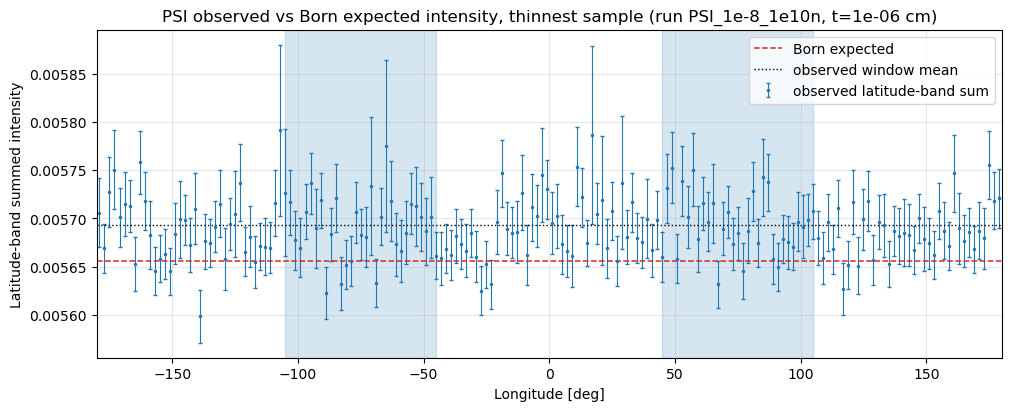

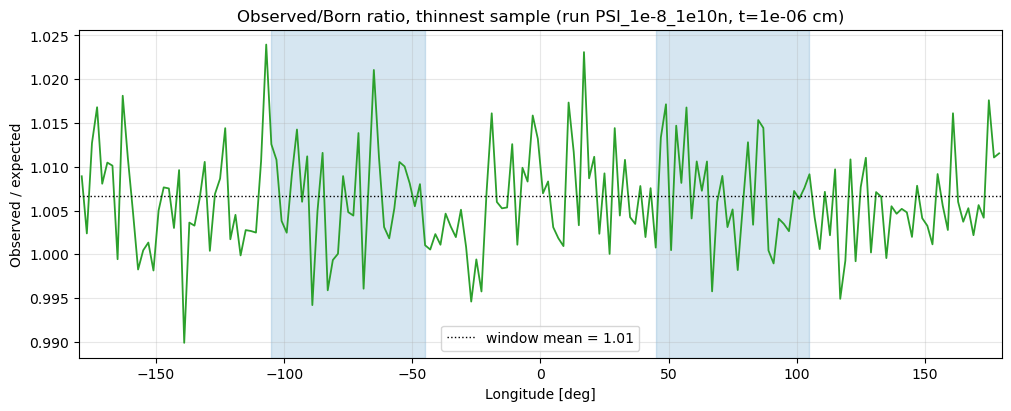

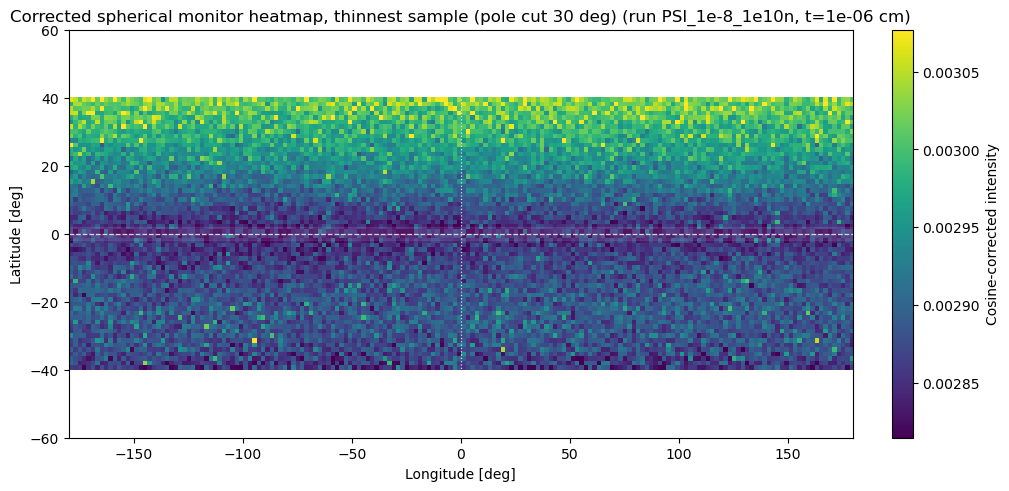

[1.00e-06 6.50e-06 1.20e-05 1.75e-05 2.30e-05 2.85e-05 3.40e-05 3.95e-05
 4.50e-05 5.05e-05 5.60e-05 6.15e-05 6.70e-05 7.25e-05 7.80e-05 8.35e-05
 8.90e-05 9.45e-05 1.00e-04]
[0.0002  0.00058 0.00096 0.00134 0.00172 0.0021  0.00248 0.00286 0.00324
 0.00362 0.004  ]


In [7]:
# Observed profile vs Born expected for the thinnest sample.
thinnest = results.loc[results['thickness_cm'].idxmin()]
thinnest_run_dir = Path(thinnest['run_dir'])
records = load_records(thinnest_run_dir)
spherical = first_available_record(records, ('sample_spherical_monitor_scattered', 'sample_spherical_monitor'))

lat_mask = latitude_mask(spherical)
longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
lon_mask = symmetric_window_mask(longitude)

expected = float(thinnest['expected_per_lon_bin'])
observed_mean = float(np.nanmean(profile[lon_mask]))
ratio = observed_mean / expected if expected > 0 else np.nan
valid = np.isfinite(profile) & (profile != 0.0)
ratio_values = np.full_like(profile, np.nan, dtype=float)
if expected > 0:
    ratio_values[valid] = profile[valid] / expected

def shade_detector_windows(ax):
    ax.axvspan(
        window_center_deg - window_width_deg / 2,
        window_center_deg + window_width_deg / 2,
        alpha=0.18,
        color='tab:blue',
    )
    ax.axvspan(
        -window_center_deg - window_width_deg / 2,
        -window_center_deg + window_width_deg / 2,
        alpha=0.18,
        color='tab:blue',
    )


fig, ax = plt.subplots(figsize=(10, 4.0), constrained_layout=True)
if profile_error is not None:
    ax.errorbar(
        longitude[valid],
        profile[valid],
        yerr=profile_error[valid],
        fmt='.',
        markersize=3,
        linewidth=0.8,
        capsize=1.5,
        label='observed latitude-band sum',
    )
else:
    ax.plot(longitude[valid], profile[valid], '.', markersize=3, label='observed latitude-band sum')
shade_detector_windows(ax)
ax.axhline(expected, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
ax.axhline(observed_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
ax.set_title(
    'PSI observed vs Born expected intensity, thinnest sample '
    f'(run {thinnest["run"]}, t={thinnest["thickness_cm"]:.6g} cm)'
)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude-band summed intensity')
ax.set_xlim(-180, 180)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.0), constrained_layout=True)
ax.plot(longitude[valid], ratio_values[valid], color='tab:green', lw=1.3)
shade_detector_windows(ax)
ax.axhline(ratio, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio:.3g}')
ax.set_title(
    'Observed/Born ratio, thinnest sample '
    f'(run {thinnest["run"]}, t={thinnest["thickness_cm"]:.6g} cm)'
)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Observed / expected')
ax.set_xlim(-180, 180)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.show()

# Corrected heatmap for the thinnest sample, using the same masking/correction as the profile.
lon_centers, lat_centers, lon_edges, lat_edges = coordinate_centers(spherical)
corrected_image = np.asarray(spherical['I'], dtype=float).copy()

if mask_direct_beam:
    center_lon, center_lat = direct_beam_center_spherical
    lon_beam = np.abs(angular_delta_deg(lon_centers, center_lon)) <= direct_beam_spherical_width_deg / 2.0
    lat_beam = np.abs(lat_centers - center_lat) <= direct_beam_spherical_height_deg / 2.0
    corrected_image[np.outer(lat_beam, lon_beam)] = np.nan

if apply_cosine_correction:
    cos_lat = np.cos(np.deg2rad(lat_centers))
    cosine_valid = np.abs(cos_lat) >= cosine_floor
    corrected_image[cosine_valid, :] /= cos_lat[cosine_valid, None]
    corrected_image[~cosine_valid, :] = np.nan

valid_latitudes = valid_latitude_mask(spherical)
corrected_image[~valid_latitudes, :] = np.nan
display_lat_edges = lat_edges.copy()
display_lat_edges[0] = max(display_lat_edges[0], -90.0 + pole_cut_deg)
display_lat_edges[-1] = min(display_lat_edges[-1], 90.0 - pole_cut_deg)

vmin = np.nanpercentile(corrected_image, 1.0)
vmax = np.nanpercentile(corrected_image, 99.5)
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.imshow(
    corrected_image,
    origin='lower',
    aspect='auto',
    extent=[lon_edges[0], lon_edges[-1], display_lat_edges[0], display_lat_edges[-1]],
    interpolation='nearest',
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
)
ax.axhline(0.0, color='white', linestyle='--', linewidth=0.9, alpha=0.8)
ax.axvline(0.0, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
ax.axhspan(-latitude_halfwidth_deg, latitude_halfwidth_deg, color='white', alpha=0.08)
ax.set_title(
    f'Corrected spherical monitor heatmap, thinnest sample (pole cut {pole_cut_deg:g} deg) '
    f'(run {thinnest["run"]}, t={thinnest["thickness_cm"]:.6g} cm)'
)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
fig.colorbar(im, ax=ax, label='Cosine-corrected intensity')
plt.show()

print(np.linspace(1e-6,1e-4, 19))
print(np.linspace(2e-4,4e-3, 11))
